# M8 — SQL: Projeto | Análise de Crédito

  M8 — PROJETO SQL: ANÁLISE DE CRÉDITO
  Storytelling com Dados | EBAC
Dados carregados da web — 10127 clientes × 16 colunas
Dataset pronto: 10127 clientes × 16 variáveis

Colunas encontradas:
['id', 'default', 'idade', 'sexo', 'dependentes', 'escolaridade', 'estado_civil', 'salario_anual', 'tipo_cartao', 'meses_de_relacionamento', 'qtd_produtos', 'iteracoes_12m', 'meses_inativo_12m', 'limite_credito', 'valor_transacoes_12m', 'qtd_transacoes_12m']

Primeiras linhas:
       id  default  idade sexo  dependentes        escolaridade estado_civil  salario_anual tipo_cartao  meses_de_relacionamento  qtd_produtos  iteracoes_12m  meses_inativo_12m  limite_credito  valor_transacoes_12m  qtd_transacoes_12m
768805383        0     45    M            3        ensino medio       casado    $60K - $80K        blue                       39             5              3                  1        12691.51               1144.90                  42
818770008        0     49    F            5            mest

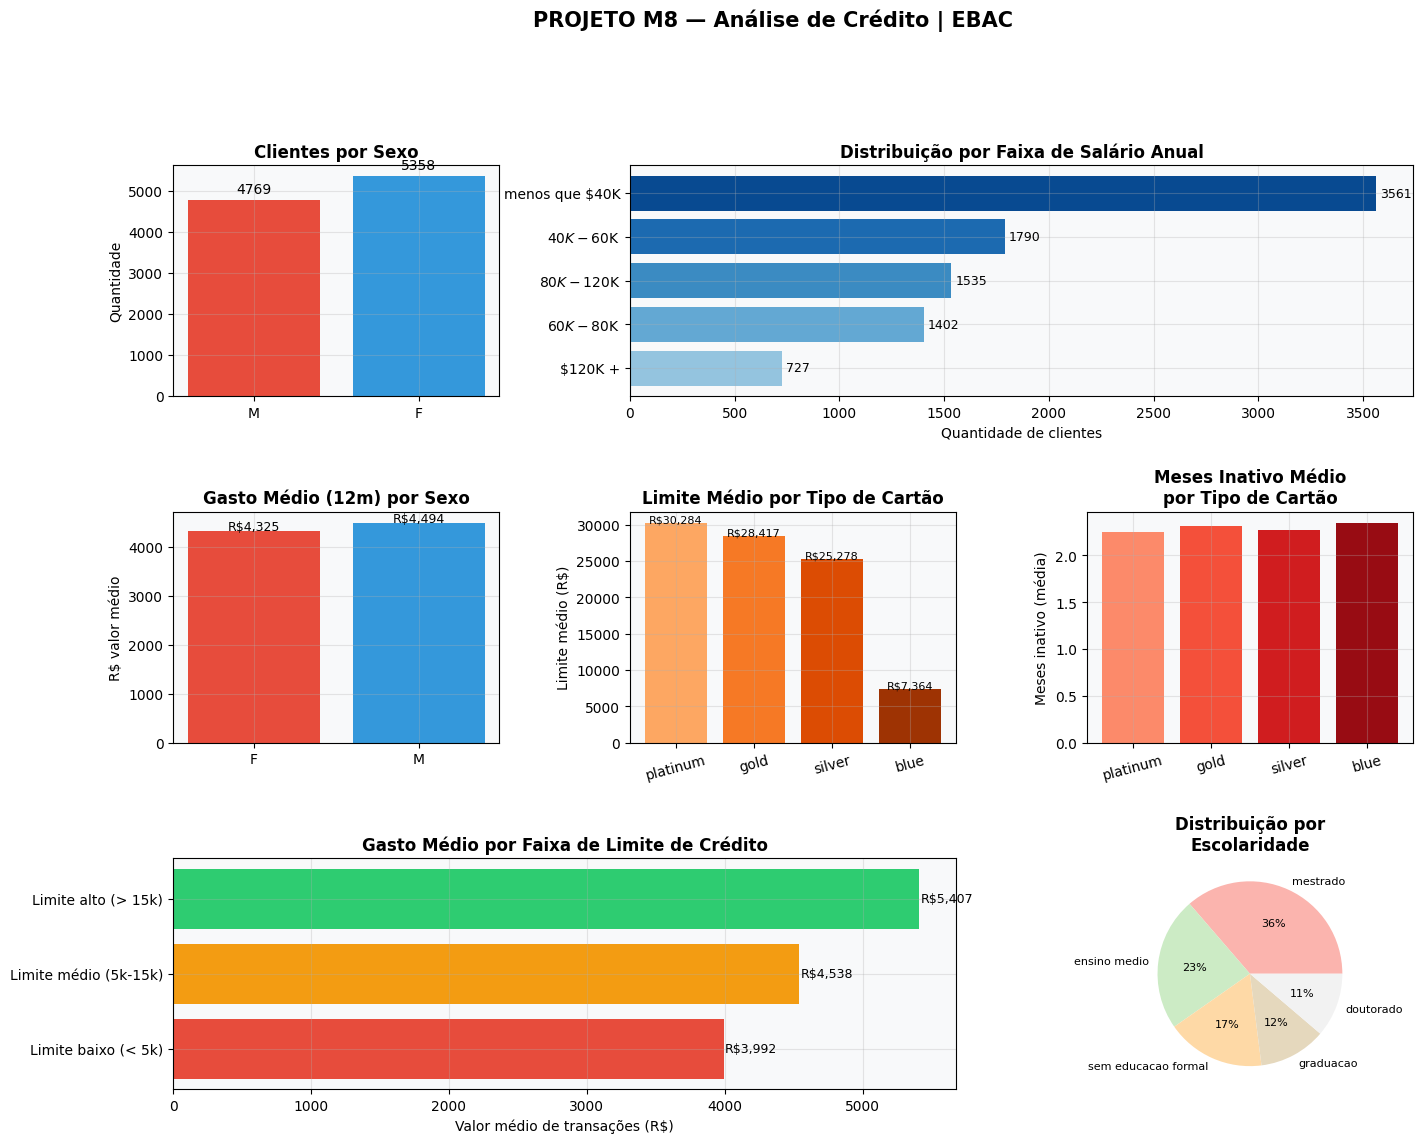

Gráfico salvo como 'analise_credito.png'

╔══════════════════════════════════════════════════════════════╗
║      STORYTELLING — CONCLUSÕES DA ANÁLISE DE CRÉDITO        ║
╚══════════════════════════════════════════════════════════════╝

 PERFIL DA BASE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 • 10,127 clientes analisados
 • Homens: 4,769 clientes (47%)
 • Mulheres: 5,358 clientes (53%)
 • Faixa salarial predominante: menos que $40K
 • Cartão mais comum: blue

 COMPORTAMENTO DE GASTOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 • Homens gastam em média  R$4,494.20/ano em transações
 • Mulheres gastam em média R$4,324.82/ano em transações
 • Clientes com limite alto tendem a apresentar maior valor médio de transações.

 INSIGHT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 1. Clientes inativos por 3 meses ou mais e com alto valor de compra
    podem ser prioridade em ações de retenção.

 2. Segmentos com maior limite e maior gasto mé

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   M8 — SQL: Projeto | Análise de Crédito                    ║
# ║   EBAC | Storytelling com Dados                             ║
# ╚══════════════════════════════════════════════════════════════╝

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import sqlite3
import warnings

warnings.filterwarnings("ignore")

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "#f8f9fa"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("=" * 65)
print("  M8 — PROJETO SQL: ANÁLISE DE CRÉDITO")
print("  Storytelling com Dados | EBAC")
print("=" * 65)



# 1) CARREGAMENTO DOS DADOS


url = "https://raw.githubusercontent.com/andre-marcos-perez/ebac-course-utils/main/dataset/credito.csv"

colunas_esperadas = [
    "id",
    "default",
    "idade",
    "sexo",
    "dependentes",
    "escolaridade",
    "estado_civil",
    "salario_anual",
    "tipo_cartao",
    "meses_de_relacionamento",
    "qtd_produtos",
    "iteracoes_12m",
    "meses_inativo_12m",
    "limite_credito",
    "valor_transacoes_12m",
    "qtd_transacoes_12m",
]

try:
    df = pd.read_csv(url)
    print(f"Dados carregados da web — {df.shape[0]} clientes × {df.shape[1]} colunas")
except Exception as erro:
    print("⚠ Não consegui carregar o CSV da web. Usando base local simulada para o exercício rodar.")
    print("Erro original:", erro)

    np.random.seed(42)
    n = 2564
    df = pd.DataFrame({
        "id": np.arange(100000000, 100000000 + n),
        "default": np.random.choice([0, 1], n, p=[0.84, 0.16]),
        "idade": np.random.randint(26, 73, n),
        "sexo": np.random.choice(["M", "F"], n, p=[0.61, 0.39]),
        "dependentes": np.random.randint(0, 6, n),
        "escolaridade": np.random.choice(
            ["ensino medio", "graduacao", "mestrado", "doutorado", "sem educacao formal", "na"], n
        ),
        "estado_civil": np.random.choice(["casado", "solteiro", "divorciado", "na"], n),
        "salario_anual": np.random.choice(
            ["menos que $40K", "$40K - $60K", "$60K - $80K", "$80K - $120K", "$120K +", "na"], n
        ),
        "tipo_cartao": np.random.choice(["blue", "silver", "gold", "platinum"], n, p=[0.92, 0.06, 0.015, 0.005]),
        "meses_de_relacionamento": np.random.randint(12, 60, n),
        "qtd_produtos": np.random.randint(1, 7, n),
        "iteracoes_12m": np.random.randint(0, 7, n),
        "meses_inativo_12m": np.random.randint(0, 7, n),
        "limite_credito": np.round(np.random.uniform(500, 25000, n), 2),
        "valor_transacoes_12m": np.round(np.random.uniform(500, 5000, n), 2),
        "qtd_transacoes_12m": np.random.randint(10, 120, n),
    })

# Limpa nomes de colunas, mas NÃO força 13 nomes em uma base que tem 16 colunas.
# Esse era o erro anterior: ValueError: Length mismatch.
df.columns = [str(c).strip() for c in df.columns]

# Caso o CSV venha sem cabeçalho ou com alguma variação, tenta corrigir apenas se o número bater.
if len(df.columns) == len(colunas_esperadas) and set(colunas_esperadas).difference(df.columns):
    df.columns = colunas_esperadas

# Se por algum motivo vierem colunas extras, mantemos as extras.
# Se faltarem colunas essenciais, paramos com uma mensagem clara.
colunas_essenciais = [
    "idade",
    "sexo",
    "dependentes",
    "escolaridade",
    "estado_civil",
    "salario_anual",
    "tipo_cartao",
    "qtd_produtos",
    "iteracoes_12m",
    "meses_inativo_12m",
    "limite_credito",
    "valor_transacoes_12m",
    "qtd_transacoes_12m",
]

faltando = [c for c in colunas_essenciais if c not in df.columns]
if faltando:
    raise ValueError(f"Colunas essenciais ausentes no dataset: {faltando}")



# 2) TRATAMENTO DE TIPOS NUMÉRICOS


def converter_numero_brasileiro(serie):
    """
    Converte valores como '12.691,51' para 12691.51.
    Se a coluna já for numérica, apenas retorna convertida.
    """
    if pd.api.types.is_numeric_dtype(serie):
        return pd.to_numeric(serie, errors="coerce")

    return pd.to_numeric(
        serie.astype(str)
             .str.strip()
             .str.replace(".", "", regex=False)
             .str.replace(",", ".", regex=False),
        errors="coerce"
    )

colunas_numericas = [
    "id",
    "default",
    "idade",
    "dependentes",
    "meses_de_relacionamento",
    "qtd_produtos",
    "iteracoes_12m",
    "meses_inativo_12m",
    "limite_credito",
    "valor_transacoes_12m",
    "qtd_transacoes_12m",
]

for coluna in colunas_numericas:
    if coluna in df.columns:
        df[coluna] = converter_numero_brasileiro(df[coluna])

print(f"Dataset pronto: {df.shape[0]} clientes × {df.shape[1]} variáveis")
print("\nColunas encontradas:")
print(list(df.columns))
print("\nPrimeiras linhas:")
print(df.head(5).to_string(index=False))



# 3) SQLITE — SIMULA O ATHENA DENTRO DO COLAB


con = sqlite3.connect(":memory:")
df.to_sql("credito", con, index=False, if_exists="replace")

print("\n Tabela SQL 'credito' criada no SQLite.")



# 4) QUERIES DO MATERIAL DE APOIO


print("\n" + "=" * 65)
print("QUERIES DO MATERIAL DE APOIO")
print("=" * 65)

# Q1 — primeiras linhas
q1 = pd.read_sql_query("SELECT * FROM credito LIMIT 10", con)
print("\n[Q1] SELECT * LIMIT 10:")
print(q1.to_string(index=False))
q1.to_csv("query_1.csv", index=False)

# Q2 — total de registros
q2 = pd.read_sql_query("SELECT count(*) AS total_clientes FROM credito", con)
print(f"\n[Q2] Total de clientes: {q2.iloc[0, 0]:,}")
q2.to_csv("query_2.csv", index=False)

# Q3 — escolaridade distintas
q3 = pd.read_sql_query("SELECT DISTINCT escolaridade FROM credito", con)
print("\n[Q3] Escolaridades únicas:")
print(q3.to_string(index=False))
q3.to_csv("query_3.csv", index=False)

# Q4 — por salário anual
q4 = pd.read_sql_query("""
SELECT count(*) AS qtd, salario_anual
FROM credito
GROUP BY salario_anual
ORDER BY qtd DESC
""", con)
print("\n[Q4] Clientes por salário anual:")
print(q4.to_string(index=False))
q4.to_csv("query_4.csv", index=False)

# Q5 — por sexo
q5 = pd.read_sql_query("""
SELECT count(*) AS qtd, sexo
FROM credito
GROUP BY sexo
""", con)
print("\n[Q5] Clientes por sexo:")
print(q5.to_string(index=False))
q5.to_csv("query_5.csv", index=False)

# Q6 — maior limite por escolaridade/cartão/sexo
q6 = pd.read_sql_query("""
SELECT
    max(limite_credito) AS limite_credito,
    escolaridade,
    tipo_cartao,
    sexo
FROM credito
WHERE escolaridade != 'na'
  AND tipo_cartao != 'na'
GROUP BY escolaridade, tipo_cartao, sexo
ORDER BY limite_credito DESC
LIMIT 10
""", con)
print("\n[Q6] Maior limite por escolaridade, cartão e sexo — top 10:")
print(q6.round(2).to_string(index=False))
q6.to_csv("query_6.csv", index=False)

# Q7 — estatísticas de gasto por sexo
q7 = pd.read_sql_query("""
SELECT
    max(valor_transacoes_12m) AS maior_valor_gasto,
    avg(valor_transacoes_12m) AS media_valor_gasto,
    min(valor_transacoes_12m) AS min_valor_gasto,
    sexo
FROM credito
GROUP BY sexo
""", con)
print("\n[Q7] Estatísticas de gasto por sexo:")
print(q7.round(2).to_string(index=False))
q7.to_csv("query_7.csv", index=False)

# Q8 — média de produtos, transações e limite por sexo e salário
q8 = pd.read_sql_query("""
SELECT
    avg(qtd_produtos) AS qts_produtos,
    avg(valor_transacoes_12m) AS media_valor_transacoes,
    avg(limite_credito) AS media_limite,
    sexo,
    salario_anual
FROM credito
WHERE salario_anual != 'na'
GROUP BY sexo, salario_anual
ORDER BY avg(valor_transacoes_12m) DESC
""", con)
print("\n[Q8] Média produtos/transações/limite por sexo e salário:")
print(q8.round(2).to_string(index=False))
q8.to_csv("query_8.csv", index=False)



# 5) ANÁLISE EXTRA — STORYTELLING


print("\n" + "=" * 65)
print("ANÁLISE EXTRA — STORYTELLING COM DADOS")
print("=" * 65)

# Extra 1 — perfil por tipo de cartão
q_extra1 = pd.read_sql_query("""
SELECT
    tipo_cartao,
    count(*) AS qtd_clientes,
    round(avg(limite_credito), 2) AS media_limite,
    round(avg(valor_transacoes_12m), 2) AS media_gasto,
    round(avg(meses_inativo_12m), 2) AS media_inatividade
FROM credito
GROUP BY tipo_cartao
ORDER BY media_limite DESC
""", con)
print("\n[Extra 1] Perfil por tipo de cartão:")
print(q_extra1.to_string(index=False))
q_extra1.to_csv("extra_1_perfil_cartao.csv", index=False)

# Extra 2 — clientes inativos de alto valor
q_extra2 = pd.read_sql_query("""
SELECT
    salario_anual,
    count(*) AS inativos_alto_valor,
    round(avg(limite_credito), 2) AS media_limite
FROM credito
WHERE meses_inativo_12m >= 3
  AND valor_transacoes_12m > 2000
  AND salario_anual != 'na'
GROUP BY salario_anual
ORDER BY inativos_alto_valor DESC
""", con)
print("\n[Extra 2] Clientes inativos com alto valor de compra:")
print(q_extra2.to_string(index=False))
q_extra2.to_csv("extra_2_inativos_alto_valor.csv", index=False)

# Extra 3 — correlação uso x limite
q_extra3 = pd.read_sql_query("""
SELECT
    CASE
        WHEN limite_credito < 5000 THEN 'Limite baixo (< 5k)'
        WHEN limite_credito < 15000 THEN 'Limite médio (5k-15k)'
        ELSE 'Limite alto (> 15k)'
    END AS faixa_limite,
    count(*) AS qtd,
    round(avg(valor_transacoes_12m), 2) AS media_gasto,
    round(avg(qtd_transacoes_12m), 2) AS media_qtd_transacoes
FROM credito
GROUP BY faixa_limite
ORDER BY media_gasto DESC
""", con)
print("\n[Extra 3] Comportamento de gastos por faixa de limite:")
print(q_extra3.to_string(index=False))
q_extra3.to_csv("extra_3_faixa_limite.csv", index=False)



# 6) VISUALIZAÇÕES — STORYTELLING


print("\n Gerando visualizações...")

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.5, wspace=0.4)

# 1. Distribuição por sexo
ax1 = fig.add_subplot(gs[0, 0])
sexo_data = q5.sort_values("qtd")
cores_sexo = ["#e74c3c", "#3498db"]
bars = ax1.bar(sexo_data["sexo"], sexo_data["qtd"], color=cores_sexo[:len(sexo_data)])
ax1.bar_label(bars, fmt="%d", padding=3, fontsize=10)
ax1.set_title("Clientes por Sexo", fontweight="bold")
ax1.set_ylabel("Quantidade")

# 2. Distribuição por salário
ax2 = fig.add_subplot(gs[0, 1:])
sal = q4[q4["salario_anual"] != "na"].sort_values("qtd", ascending=True)
cores_sal = plt.cm.Blues(np.linspace(0.4, 0.9, max(len(sal), 1)))
bars2 = ax2.barh(sal["salario_anual"], sal["qtd"], color=cores_sal[:len(sal)])
ax2.bar_label(bars2, fmt="%d", padding=3, fontsize=9)
ax2.set_title("Distribuição por Faixa de Salário Anual", fontweight="bold")
ax2.set_xlabel("Quantidade de clientes")

# 3. Gasto médio por sexo
ax3 = fig.add_subplot(gs[1, 0])
bars3 = ax3.bar(q7["sexo"], q7["media_valor_gasto"].round(0), color=cores_sexo[:len(q7)])
ax3.set_title("Gasto Médio (12m) por Sexo", fontweight="bold")
ax3.set_ylabel("R$ valor médio")
for i, v in enumerate(q7["media_valor_gasto"]):
    ax3.text(i, v + 20, f"R${v:,.0f}", ha="center", fontsize=9)

# 4. Limite médio por cartão
ax4 = fig.add_subplot(gs[1, 1])
cores_cartao = plt.cm.Oranges(np.linspace(0.4, 0.9, max(len(q_extra1), 1)))
ax4.bar(q_extra1["tipo_cartao"], q_extra1["media_limite"], color=cores_cartao[:len(q_extra1)])
ax4.set_title("Limite Médio por Tipo de Cartão", fontweight="bold")
ax4.set_ylabel("Limite médio (R$)")
ax4.tick_params(axis="x", rotation=15)
for i, v in enumerate(q_extra1["media_limite"]):
    ax4.text(i, v + 50, f"R${v:,.0f}", ha="center", fontsize=8)

# 5. Inatividade por tipo de cartão
ax5 = fig.add_subplot(gs[1, 2])
cores_inat = plt.cm.Reds(np.linspace(0.4, 0.9, max(len(q_extra1), 1)))
ax5.bar(q_extra1["tipo_cartao"], q_extra1["media_inatividade"], color=cores_inat[:len(q_extra1)])
ax5.set_title("Meses Inativo Médio\npor Tipo de Cartão", fontweight="bold")
ax5.set_ylabel("Meses inativo (média)")
ax5.tick_params(axis="x", rotation=15)

# 6. Gasto por faixa de limite
ax6 = fig.add_subplot(gs[2, :2])
faixa = q_extra3.sort_values("media_gasto", ascending=True)
cores_faixa = ["#e74c3c", "#f39c12", "#2ecc71"][:len(faixa)]
ax6.barh(faixa["faixa_limite"], faixa["media_gasto"], color=cores_faixa)
ax6.set_title("Gasto Médio por Faixa de Limite de Crédito", fontweight="bold")
ax6.set_xlabel("Valor médio de transações (R$)")
for i, v in enumerate(faixa["media_gasto"]):
    ax6.text(v + 10, i, f"R${v:,.0f}", va="center", fontsize=9)

# 7. Distribuição por escolaridade
ax7 = fig.add_subplot(gs[2, 2])
esc = df[df["escolaridade"] != "na"]["escolaridade"].value_counts()
if len(esc) > 0:
    ax7.pie(
        esc.values,
        labels=esc.index,
        autopct="%1.0f%%",
        colors=plt.cm.Pastel1(np.linspace(0, 1, len(esc))),
        textprops={"fontsize": 8},
    )
ax7.set_title("Distribuição por\nEscolaridade", fontweight="bold")

plt.suptitle("PROJETO M8 — Análise de Crédito | EBAC", fontsize=15, fontweight="bold", y=1.01)
plt.savefig("analise_credito.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico salvo como 'analise_credito.png'")



# 7) CONCLUSÕES — STORYTELLING


n_total = int(q2.iloc[0, 0])

def obter_qtd_por_sexo(sexo):
    valores = q5.loc[q5["sexo"] == sexo, "qtd"].values
    return int(valores[0]) if len(valores) else 0

def obter_media_gasto_por_sexo(sexo):
    valores = q7.loc[q7["sexo"] == sexo, "media_valor_gasto"].values
    return float(valores[0]) if len(valores) else 0.0

n_masc = obter_qtd_por_sexo("M")
n_fem = obter_qtd_por_sexo("F")
gasto_m = obter_media_gasto_por_sexo("M")
gasto_f = obter_media_gasto_por_sexo("F")

cartao_mais_comum = (
    q_extra1.sort_values("qtd_clientes", ascending=False)["tipo_cartao"].iloc[0]
    if len(q_extra1) else "não identificado"
)

faixa_salarial_predominante = (
    q4[q4["salario_anual"] != "na"].sort_values("qtd", ascending=False)["salario_anual"].iloc[0]
    if len(q4[q4["salario_anual"] != "na"]) else "não identificado"
)

print(f"""
╔══════════════════════════════════════════════════════════════╗
║      STORYTELLING — CONCLUSÕES DA ANÁLISE DE CRÉDITO        ║
╚══════════════════════════════════════════════════════════════╝

 PERFIL DA BASE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 • {n_total:,} clientes analisados
 • Homens: {n_masc:,} clientes ({(n_masc/n_total*100) if n_total else 0:.0f}%)
 • Mulheres: {n_fem:,} clientes ({(n_fem/n_total*100) if n_total else 0:.0f}%)
 • Faixa salarial predominante: {faixa_salarial_predominante}
 • Cartão mais comum: {cartao_mais_comum}

 COMPORTAMENTO DE GASTOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 • Homens gastam em média  R${gasto_m:,.2f}/ano em transações
 • Mulheres gastam em média R${gasto_f:,.2f}/ano em transações
 • Clientes com limite alto tendem a apresentar maior valor médio de transações.

 INSIGHT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 1. Clientes inativos por 3 meses ou mais e com alto valor de compra
    podem ser prioridade em ações de retenção.

 2. Segmentos com maior limite e maior gasto médio podem receber
    ações de relacionamento e ofertas de produtos premium.

 3. A comparação entre limite, transações e tipo de cartão ajuda a
    identificar oportunidades de upsell e melhor gestão de crédito.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
""")

print("Arquivos gerados:")
print(" - query_1.csv até query_8.csv")
print(" - extra_1_perfil_cartao.csv")
print(" - extra_2_inativos_alto_valor.csv")
print(" - extra_3_faixa_limite.csv")
print(" - analise_credito.png")

